# Multiscale 1D RM-CLEAN

Standard (Hogbom) RM-CLEAN models the Faraday dispersion function (FDF) as a sum
of delta functions. For a **Faraday-thick** source, whose FDF is genuinely
extended in Faraday depth, that becomes a picket fence of deltas: it still fits
the data, but the model is a spray of components that also soaks up noise.
Multiscale RM-CLEAN (Cornwell 2008; Offringa & Smirnov 2017) cleans with
extended kernels, so an extended feature is modelled by a few broad components
instead.

Two things decide whether multiscale can help:

- **Resolution**: the Faraday thickness $\Delta\phi$ must exceed the RMSF FWHM,
  else the source is a point as far as CLEAN can tell.
- **Recoverability**: $\Delta\phi$ must be below the largest recoverable scale
  $\phi_{\rm max} = \pi / \lambda^2_{\rm min}$ (set by the highest frequency),
  else the structure is resolved out and no algorithm recovers it.

We run the same three regimes (thin, marginal, resolved-thick) on two very
different coverages:

| Coverage | Bands | RMSF FWHM | $\phi_{\rm max}$ |
|---|---|---|---|
| **RACS-all** | 3 narrow bands (0.8-1.8 GHz) | coarse (~34 rad m$^{-2}$) | only ~3x FWHM: little room |
| **GMIMS-DRAGONS** | continuous 0.3-1.8 GHz | fine (~6 rad m$^{-2}$) | ~19x FWHM: lots of room |

For each thick slab we also clean **two Faraday-thin components at the same
separation**, to check that multiscale adapts to the source: extended for a
genuine slab, compact for two points.

Recovered flux is comparable to single-scale across the board: multiscale
recovers no *extra* flux, because a Burn slab genuinely depolarises (the $Q,U$
signal shrinks as $\mathrm{sinc}(\Delta\phi\,\lambda^2)$), so a thick source's
observed flux really is lower, and CLEAN cannot invent what depolarisation
removed. What multiscale buys is a model matched to the source (extended for a
slab, compact for points), not more flux and not less work.

**On counting.** These runs have no major cycle (no invert-and-subtract against
the data), so there are two counts. Single-scale places one delta per **minor
iteration** (`n_iter`). Multiscale's `n_iter` is the number of **minor cycles**
(scale re-selections), each running an inner per-scale Hogbom loop; its total
component-placement count is `n_sub_minor_iter`. Multiscale reaches convergence
in far fewer *minor cycles*, but the honest work comparison is
`n_sub_minor_iter` against single-scale's `n_iter`, and by that measure
multiscale places **more** components in these (realistic, sidelobe-rich)
RMSFs, not fewer. So we quote both and do not sell multiscale as "faster": its
value is the model, not the component count.</cell id="0">

## Setup

In [47]:
from __future__ import annotations

import logging

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from rm_lite.tools_1d import rmclean, rmsynth
from rm_lite.utils.logging import quiet_logs
from rm_lite.utils.synthesis import freq_to_lambda2

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(7)

# Source and CLEAN constants, shared by every case.
RM_RADM2 = 25.0  # true Faraday depth of the source
PSI0_DEG = 10.0  # intrinsic polarisation angle
FRAC_POL = 0.5  # intrinsic (peak) fractional polarisation
RMS_NOISE = 0.02  # noise per Q, U channel
AUTO_MASK = 10.0  # mask threshold, in units of the FDF noise
AUTO_THRESHOLD = 0.5  # clean threshold in FDF noise units; the mask lets us go deep
MULTISCALE_MAX_ITER_SUB_MINOR = 3000
SCALE_BIAS = 0.8  # library default; engages scales, keeps a thin source ~compact
SCALE_BIAS_HIGH = 0.95  # near 1: scale 0 almost always wins (~ single-scale)
SCALE_BIAS_LOW = 0.6  # WSClean's image-domain default; over-extends in the RMSF domain

# Faraday thickness of each case, in units of the RMSF FWHM. RACS-all can only
# reach ~3x FWHM, so its "resolved" case is milder than GMIMS-DRAGONS' (~19x).
DELTA_THIN = 0.0
DELTA_MARGINAL = 1.0
DELTA_RESOLVED_RACS = 2.0
DELTA_RESOLVED_GMIMS = 6.0


def burn_slab(
    lambda_sq_arr_m2: NDArray[np.float64], delta_rm_radm2: float
) -> NDArray[np.complex128]:
    """Burn slab P(lambda^2); delta_rm=0 is a Faraday-thin source."""
    return (
        FRAC_POL
        * np.exp(2j * (np.deg2rad(PSI0_DEG) + RM_RADM2 * lambda_sq_arr_m2))
        * np.sinc(delta_rm_radm2 * lambda_sq_arr_m2 / np.pi)
    ).astype(np.complex128)


def two_thin_points(
    lambda_sq_arr_m2: NDArray[np.float64], separation_radm2: float
) -> NDArray[np.complex128]:
    """Two Faraday-thin components at RM +/- separation/2, same total flux."""
    return (
        FRAC_POL
        * np.exp(2j * (np.deg2rad(PSI0_DEG) + RM_RADM2 * lambda_sq_arr_m2))
        * np.cos(separation_radm2 * lambda_sq_arr_m2)
    ).astype(np.complex128)


def clean_stats(res) -> tuple[float, int, int]:
    """(mom0, minor iterations, component steps) for a 1D clean result.

    Single-scale places one component per minor iteration, so the two counts are
    equal. Multiscale's minor count is scale re-selections; `n_sub_minor_iter` is
    the total per-scale Hogbom steps, i.e. the count directly comparable to a
    single-scale iteration count.
    """
    mom0 = float(res.fdf_parameters["mom0_debias"][0])
    minor = int(np.ravel(res.clean_parameters["n_iter"])[0])
    comps = int(np.ravel(res.clean_parameters["n_sub_minor_iter"])[0])
    return mom0, minor, comps

One plot function, a 2x2 grid comparing single-scale (left) and multiscale
(right). The top row shows the FDF (true, dirty, clean); the bottom row shows the
CLEAN model and residual with the mask and threshold levels. The true FDF is a
delta for a thin source, a tophat for a slab, two deltas for the two-point case.</cell id="3">

In [48]:
def plot_clean(synth, single, multi, source_kind, extent, rmsf_fwhm, title):
    """2x2 comparison. Columns: single-scale vs multiscale. Top row: the FDF
    (true, dirty, clean). Bottom row: the CLEAN model, residual, and the mask and
    threshold levels. Multiscale's minor-cycle and sub-minor totals are annotated
    separately."""
    phi = synth.fdf_arrs["phi_arr_radm2"].to_numpy().astype(float)
    dirty = synth.fdf_arrs["fdf_dirty_complex_arr"].to_numpy().astype(complex)

    # True (intrinsic) Faraday dispersion function: delta / tophat / two deltas.
    true_model = np.zeros_like(phi)
    if source_kind == "thin":
        true_model[np.argmin(np.abs(phi - RM_RADM2))] = FRAC_POL
    elif source_kind == "slab":
        true_model[np.abs(phi - RM_RADM2) <= extent / 2] = FRAC_POL
    elif source_kind == "points":
        for centre in (RM_RADM2 - extent / 2, RM_RADM2 + extent / 2):
            true_model[np.argmin(np.abs(phi - centre))] = FRAC_POL / 2

    half = max(4 * rmsf_fwhm, 0.8 * extent)
    fig, axs = plt.subplots(2, 2, sharex=True, sharey="row", figsize=(10, 6))
    for col, (res, name) in enumerate(
        zip((single, multi), ("single-scale", "multiscale"), strict=True)
    ):
        clean = res.fdf_arrs["fdf_clean_complex_arr"].to_numpy().astype(complex)
        model = res.fdf_arrs["fdf_model_complex_arr"].to_numpy().astype(complex)
        resid = res.fdf_arrs["fdf_residual_complex_arr"].to_numpy().astype(complex)
        mask = float(res.clean_parameters["mask"][0])
        threshold = float(res.clean_parameters["threshold"][0])
        _, minor, comps = clean_stats(res)
        count = (
            f"{minor} iters."
            if name == "single-scale"
            else f"{minor} iters.,\n{comps} sub-minor"
        )

        # Top row: the FDF.
        top = axs[0, col]
        top.plot(phi, true_model, color="0.5", ls="--", lw=1.2, label="true FDF")
        top.plot(phi, np.abs(dirty), color="k", alpha=0.35, label="dirty")
        top.plot(phi, np.abs(clean), color="k", label="clean")
        top.step(phi, np.abs(model), color="tab:red", where="mid", label="model")
        top.plot(phi, np.abs(resid), color="tab:blue", alpha=0.6, label="residual")
        top.axhline(mask, color="tab:orange", ls=":", lw=0.8, label="mask")
        top.axhline(threshold, color="tab:green", ls=":", lw=0.8, label="threshold")
        top.text(0.02, 0.95, f"{name}: {count}", transform=top.transAxes,
                 va="top", fontweight="bold")
        top.set(ylabel="|FDF|")

        # Bottom row: model, residual, mask and threshold.
        bot = axs[1, col]
        bot.step(phi, np.abs(model), color="tab:red", where="mid", label="model")
        bot.plot(phi, np.abs(resid), color="tab:blue", alpha=0.6, label="residual")
        bot.axhline(mask, color="tab:orange", ls=":", lw=0.8, label="mask")
        bot.axhline(threshold, color="tab:green", ls=":", lw=0.8, label="threshold")
        bot.set(ylabel="|model|, |residual|",
                xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
                xlim=(RM_RADM2 - half, RM_RADM2 + half))
    axs[0, 0].legend(fontsize=7, loc="upper right")
    axs[1, 0].legend(fontsize=7, loc="upper right")
    fig.suptitle(title)
    fig.tight_layout()

## RACS-all coverage

RACS observes three narrow bands (RACS-low, -mid, -high). The gaps make the
$\lambda^2$ coverage sparse, so the RMSF is broad (coarse Faraday resolution)
and, because the highest frequency is only ~1.8 GHz, the largest recoverable
scale is barely a few RMSF FWHM. There is little room for genuinely resolved
thick structure.

In [49]:
bw_low, bw_mid, bw_high = 288, 144, 288  # MHz
freq_hz = (
    np.concatenate(
        [
            np.linspace(943.5 - bw_low / 2, 943.5 + bw_low / 2, 36),
            np.linspace(1367.5 - bw_mid / 2, 1367.5 + bw_mid / 2, 9),
            np.linspace(1655.5 - bw_high / 2, 1655.5 + bw_high / 2, 9),
        ]
    )
    * u.MHz
)
freq_hz = freq_hz.to(u.Hz).value
lambda_sq = freq_to_lambda2(freq_hz)

### Thin source ($\Delta\phi = 0$)

The thin case also fixes the RMSF FWHM and $\phi_{\rm max}$ we scale the other
cases against. A point source has nothing extended to recover, so multiscale
should match single-scale on flux, and it does. Note that at the default
`scale_bias=0.8` multiscale still engages some small scales even on a point (its
model is not a single delta); pushing the bias up towards 1 keeps it a delta but
then multiscale barely differs from single-scale anywhere (see the `scale_bias`
caution near the end).</cell id="7">

In [50]:
pol = (
    burn_slab(lambda_sq, DELTA_THIN)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0, single_n, _ = clean_stats(single)
multi_mom0, multi_minor, multi_comps = clean_stats(multi)

rmsf_fwhm = float(synth.fdf_parameters["fwhm_rmsf_radm2"][0])
phi_max = float(synth.fdf_parameters["phi_max_scale_radm2"][0])
print(f"RACS-all RMSF FWHM = {rmsf_fwhm:.1f} rad/m^2")
print(
    f"max recoverable scale = {phi_max:.0f} rad/m^2 ({phi_max / rmsf_fwhm:.1f} x FWHM)"
)
print(
    f"marginal case dRM = {DELTA_MARGINAL * rmsf_fwhm:.0f} rad/m^2, "
    f"resolved case dRM = {DELTA_RESOLVED_RACS * rmsf_fwhm:.0f} rad/m^2 "
    f"({DELTA_RESOLVED_RACS * rmsf_fwhm / phi_max:.0%} of max scale)"
)

print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} minor_cycles={multi_minor} "
    f"component_steps={multi_comps}"
)

# Multiscale matches single-scale flux on the point source. (It reaches it in
# few minor cycles but many component steps; see "On counting" above.)
assert abs(multi_mom0 - single_mom0) < 0.05
assert 0.40 < multi_mom0 < 0.60

RACS-all RMSF FWHM = 34.4 rad/m^2
max recoverable scale = 113 rad/m^2 (3.3 x FWHM)
marginal case dRM = 34 rad/m^2, resolved case dRM = 69 rad/m^2 (61% of max scale)
single: mom0=0.495 iterations=57
multi:  mom0=0.493 minor_cycles=11 component_steps=265


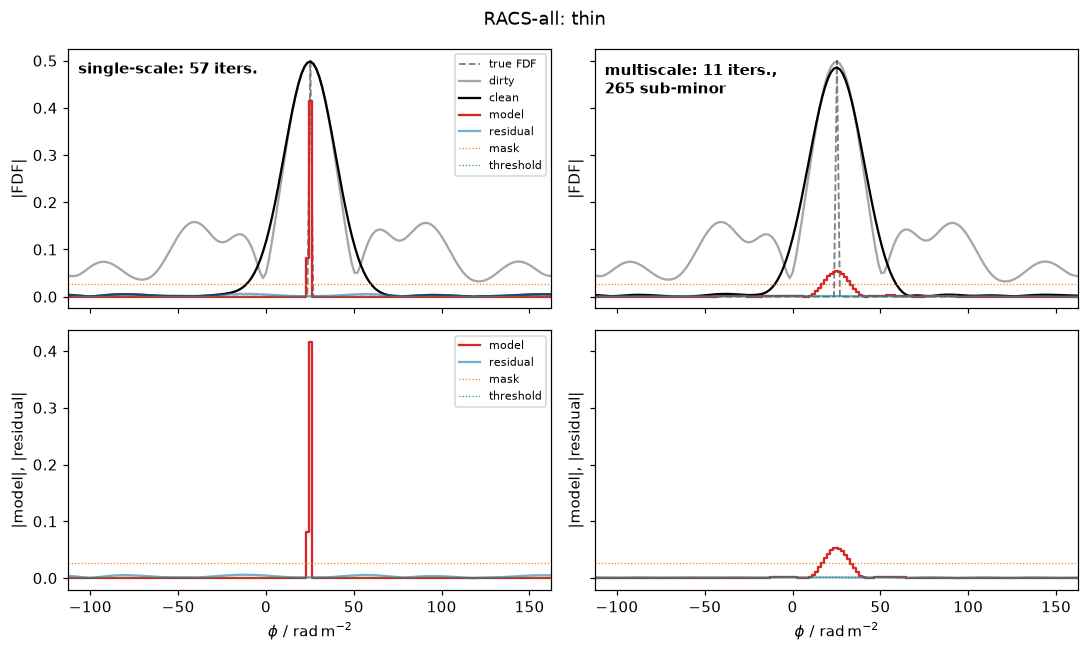

In [51]:
plot_clean(synth, single, multi, "thin", 0.0, rmsf_fwhm, "RACS-all: thin")

### Marginally resolved ($\Delta\phi \approx 1\times$ FWHM)

In [52]:
delta_rm = DELTA_MARGINAL * rmsf_fwhm

pol = (
    burn_slab(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0, single_n, _ = clean_stats(single)
multi_mom0, multi_minor, multi_comps = clean_stats(multi)

print(f"dRM={delta_rm:.0f} rad/m^2 ({DELTA_MARGINAL:.0f}x FWHM)")
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} minor_cycles={multi_minor} "
    f"component_steps={multi_comps}"
)

# Depolarised source; multiscale recovers comparable flux.
assert multi_mom0 > 0.75 * single_mom0

dRM=34 rad/m^2 (1x FWHM)
single: mom0=0.189 iterations=321
multi:  mom0=0.185 minor_cycles=12 component_steps=382


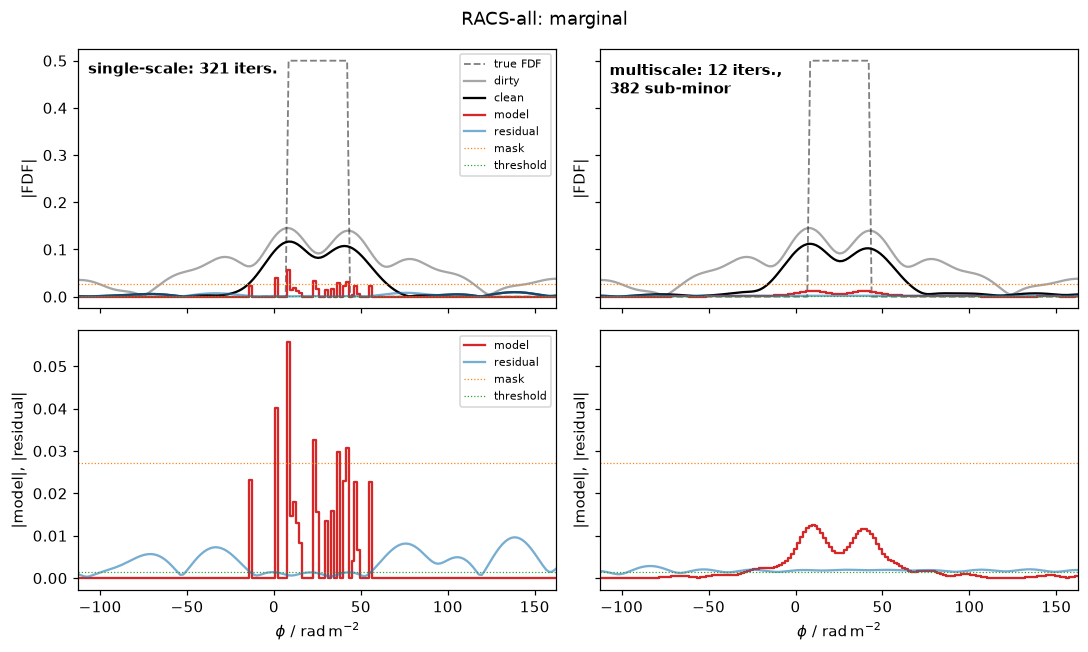

In [53]:
plot_clean(synth, single, multi, "slab", delta_rm, rmsf_fwhm, "RACS-all: marginal")

### Resolved thick ($\Delta\phi \approx 2\times$ FWHM)

About as thick as RACS-all can usefully go: the slab is over half the largest
recoverable scale and heavily depolarised. Multiscale does not recover more flux
here (the structure is near the edge of the usable window), but still describes
it as a few broad features rather than a picket fence of deltas.

In [54]:
delta_rm = DELTA_RESOLVED_RACS * rmsf_fwhm

pol = (
    burn_slab(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0, single_n, _ = clean_stats(single)
multi_mom0, multi_minor, multi_comps = clean_stats(multi)

print(
    f"dRM={delta_rm:.0f} rad/m^2 ({DELTA_RESOLVED_RACS:.0f}x FWHM, "
    f"{delta_rm / phi_max:.0%} of max scale)"
)
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} minor_cycles={multi_minor} "
    f"component_steps={multi_comps}"
)

# Heavily depolarised at the edge of the usable window; flux still comparable.
assert multi_mom0 > 0.7 * single_mom0

dRM=69 rad/m^2 (2x FWHM, 61% of max scale)
single: mom0=0.100 iterations=98
multi:  mom0=0.089 minor_cycles=14 component_steps=634


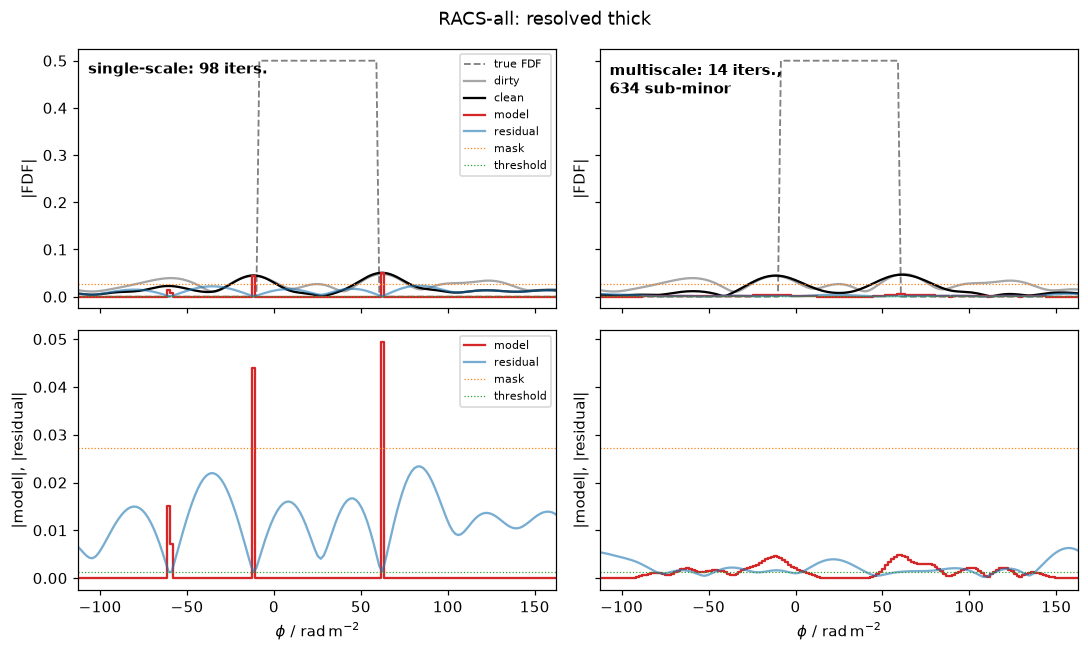

In [55]:
plot_clean(
    synth, single, multi, "slab", delta_rm, rmsf_fwhm, "RACS-all: resolved thick"
)

### Same separation, two thin points

Two Faraday-thin components separated by the same $\Delta\phi$ as the slab above.
Unlike the slab they do not depolarise, so single-scale and multiscale both
recover the full flux; multiscale still does it in far fewer iterations. The
contrast with the slab (same separation, but the slab's flux collapses) shows
that on RACS it is Faraday *thickness*, not separation, that is the problem.

In [56]:
pol = (
    two_thin_points(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0, single_n, _ = clean_stats(single)
multi_mom0, multi_minor, multi_comps = clean_stats(multi)

print(f"two thin points separated by {delta_rm:.0f} rad/m^2")
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} minor_cycles={multi_minor} "
    f"component_steps={multi_comps}"
)

# Two points do not depolarise: both recover near-full flux.
assert multi_mom0 > 0.8 * FRAC_POL

two thin points separated by 69 rad/m^2
single: mom0=0.496 iterations=107
multi:  mom0=0.504 minor_cycles=10 component_steps=499


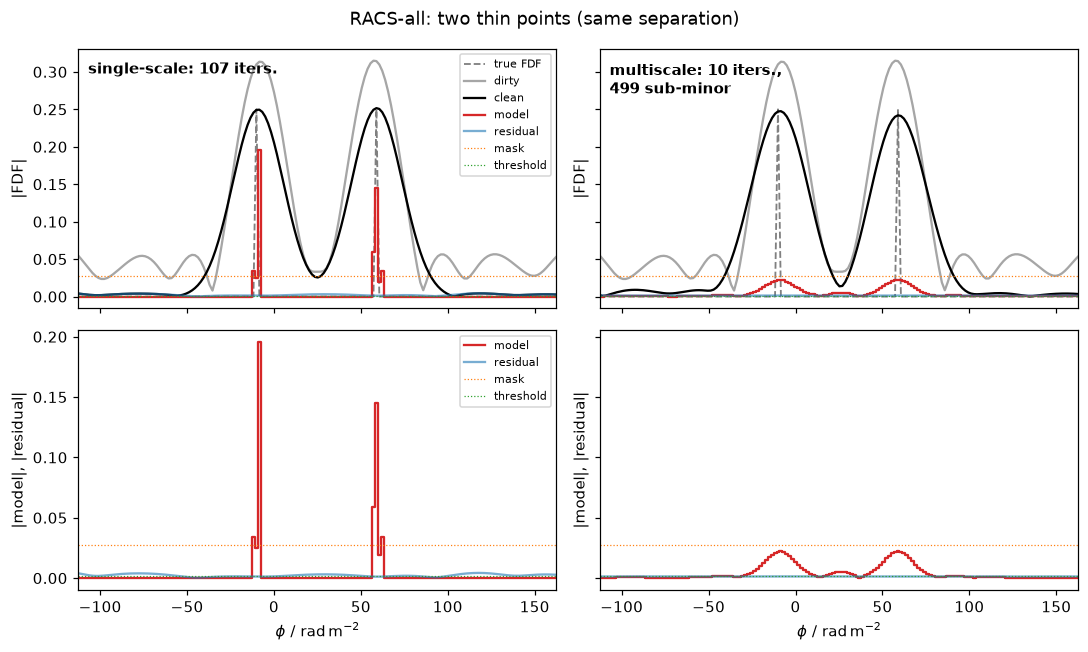

In [57]:
plot_clean(
    synth,
    single,
    multi,
    "points",
    delta_rm,
    rmsf_fwhm,
    "RACS-all: two thin points (same separation)",
)

**RACS-all takeaway:** narrow-band coverage leaves almost no room for resolved
thick sources, and they depolarise quickly, so multiscale buys no extra flux for
a slab. Two thin points at the same separation are recovered fine by both, which
pins the blame on thickness, not separation. Multiscale converges in fewer
*minor cycles* but (see the component-step counts) does not do less work.</cell id="0">

## GMIMS-DRAGONS coverage

GMIMS-DRAGONS-style coverage is continuous from 0.3 to 1.8 GHz. The dense, wide
$\lambda^2$ span gives a fine RMSF (good Faraday resolution) and a largest
recoverable scale of roughly 19 RMSF FWHM, so genuinely resolved thick structure
both exists and survives.

In [58]:
freq_hz = np.linspace(0.3e9, 1.8e9, 500)
lambda_sq = freq_to_lambda2(freq_hz)

### Thin source ($\Delta\phi = 0$)

In [59]:
pol = (
    burn_slab(lambda_sq, DELTA_THIN)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0, single_n, _ = clean_stats(single)
multi_mom0, multi_minor, multi_comps = clean_stats(multi)

rmsf_fwhm = float(synth.fdf_parameters["fwhm_rmsf_radm2"][0])
phi_max = float(synth.fdf_parameters["phi_max_scale_radm2"][0])
print(f"GMIMS-DRAGONS RMSF FWHM = {rmsf_fwhm:.1f} rad/m^2")
print(
    f"max recoverable scale = {phi_max:.0f} rad/m^2 ({phi_max / rmsf_fwhm:.1f} x FWHM)"
)
print(
    f"resolved case dRM = {DELTA_RESOLVED_GMIMS * rmsf_fwhm:.0f} rad/m^2 "
    f"({DELTA_RESOLVED_GMIMS * rmsf_fwhm / phi_max:.0%} of max scale)"
)

print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} minor_cycles={multi_minor} "
    f"component_steps={multi_comps}"
)

assert abs(multi_mom0 - single_mom0) < 0.05
assert 0.40 < multi_mom0 < 0.60

# Keep the thin-source results to compare against an over-aggressive scale_bias.
synth_thin, multi_thin = synth, multi

GMIMS-DRAGONS RMSF FWHM = 6.1 rad/m^2
max recoverable scale = 113 rad/m^2 (18.6 x FWHM)
resolved case dRM = 37 rad/m^2 (32% of max scale)
single: mom0=0.499 iterations=67
multi:  mom0=0.501 minor_cycles=17 component_steps=1689


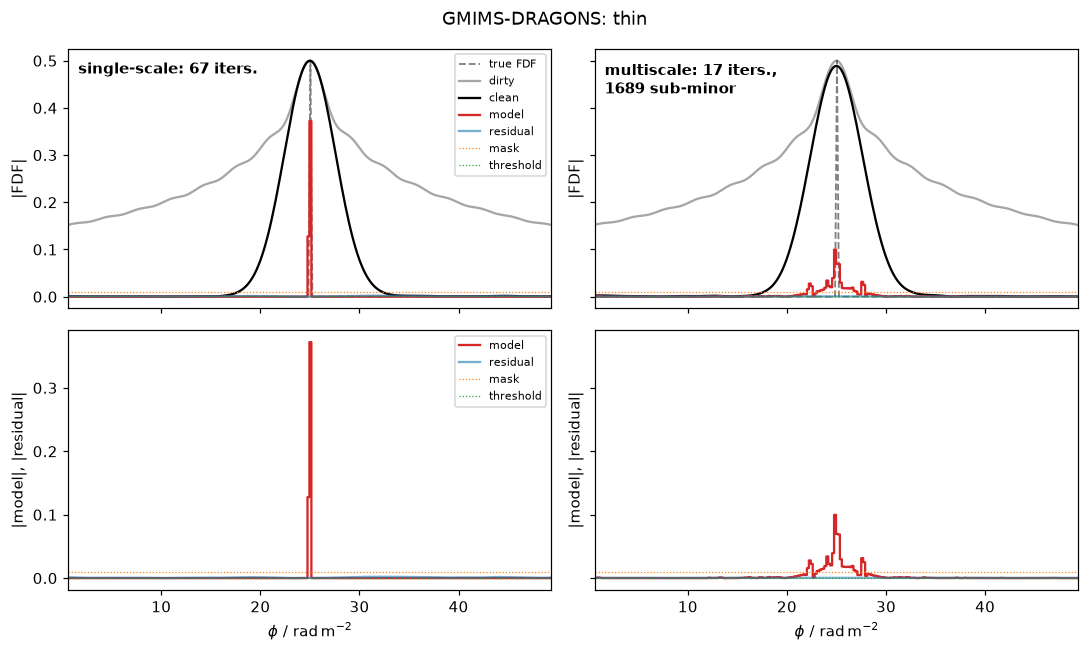

In [60]:
plot_clean(synth, single, multi, "thin", 0.0, rmsf_fwhm, "GMIMS-DRAGONS: thin")

### Marginally resolved ($\Delta\phi \approx 1\times$ FWHM)

In [61]:
delta_rm = DELTA_MARGINAL * rmsf_fwhm

pol = (
    burn_slab(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0, single_n, _ = clean_stats(single)
multi_mom0, multi_minor, multi_comps = clean_stats(multi)

print(f"dRM={delta_rm:.0f} rad/m^2 ({DELTA_MARGINAL:.0f}x FWHM)")
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} minor_cycles={multi_minor} "
    f"component_steps={multi_comps}"
)

# Comparable flux.
assert multi_mom0 > 0.95 * single_mom0

dRM=6 rad/m^2 (1x FWHM)
single: mom0=0.454 iterations=136
multi:  mom0=0.469 minor_cycles=16 component_steps=1033


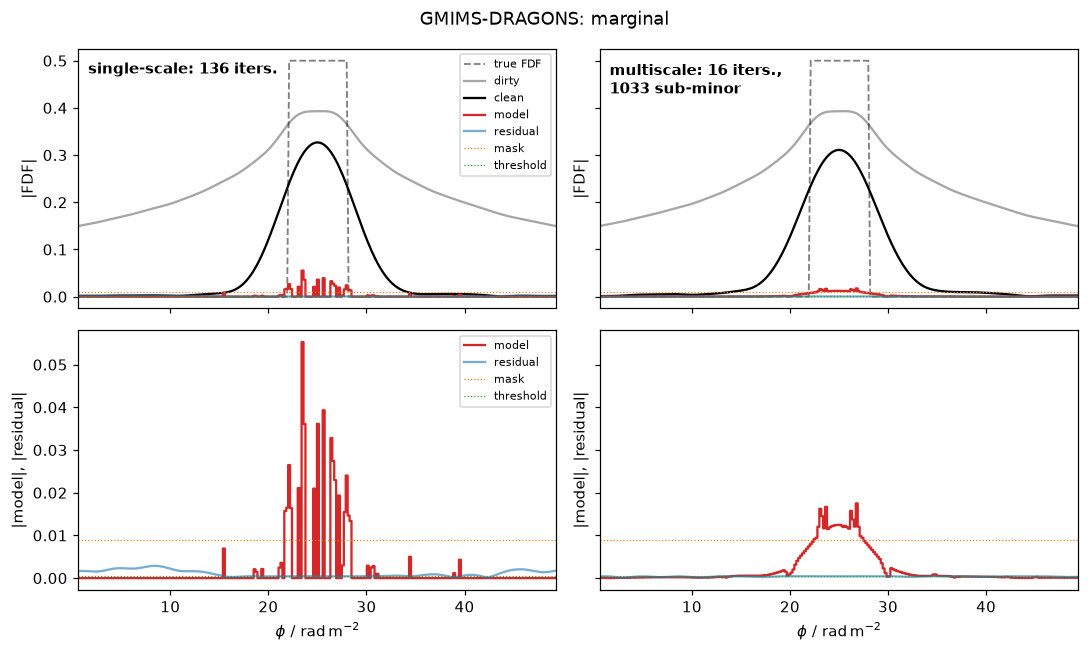

In [62]:
plot_clean(synth, single, multi, "slab", delta_rm, rmsf_fwhm, "GMIMS-DRAGONS: marginal")

### Resolved thick ($\Delta\phi \approx 6\times$ FWHM)

Now the source is genuinely resolved and well inside the recoverable window.
Flux is comparable to single-scale (a Burn slab still depolarises, so neither
recovers the full intrinsic flux). The difference is the **model**: in the plot's
bottom row multiscale spreads it across the slab rather than piling deltas at a
point. It gets there in fewer minor cycles, though not fewer component steps.</cell id="30">

In [63]:
delta_rm = DELTA_RESOLVED_GMIMS * rmsf_fwhm

pol = (
    burn_slab(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0, single_n, _ = clean_stats(single)
multi_mom0, multi_minor, multi_comps = clean_stats(multi)

multi_model = np.abs(multi.fdf_arrs["fdf_model_complex_arr"].to_numpy().astype(complex))
multi_model_chan = int((multi_model > 0.01 * multi_model.max()).sum())
print(
    f"dRM={delta_rm:.0f} rad/m^2 ({DELTA_RESOLVED_GMIMS:.0f}x FWHM, "
    f"{delta_rm / phi_max:.0%} of max scale)"
)
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} minor_cycles={multi_minor} "
    f"component_steps={multi_comps} (model spans {multi_model_chan} channels)"
)

# Comparable flux, and here is the genuine multiscale behaviour: unlike the thin
# source, the slab model spreads across many channels rather than sitting at a
# point. This is what the model+residual plot below makes visible.
assert multi_mom0 > 0.95 * single_mom0
assert multi_model_chan > 50

dRM=37 rad/m^2 (6x FWHM, 32% of max scale)
single: mom0=0.310 iterations=592
multi:  mom0=0.321 minor_cycles=22 component_steps=1227 (model spans 785 channels)


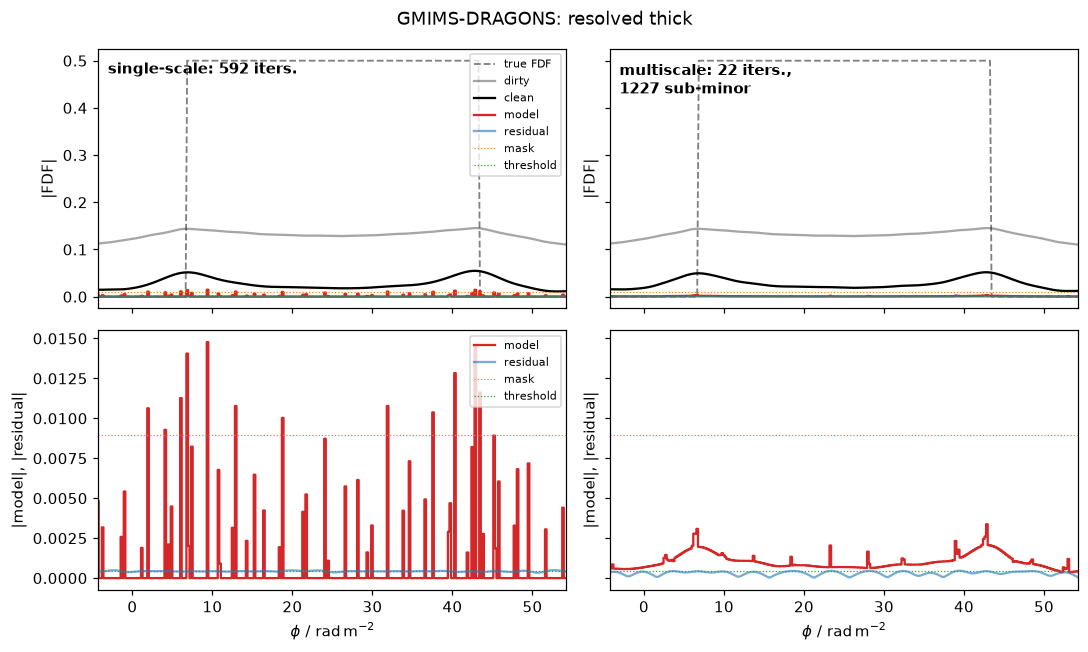

In [64]:
plot_clean(
    synth, single, multi, "slab", delta_rm, rmsf_fwhm, "GMIMS-DRAGONS: resolved thick"
)

### Same separation, two thin points

The same $\Delta\phi$ separation as the resolved slab, but two thin components.
These do not depolarise, so both algorithms recover the full flux. Compare the
model (bottom row) with the slab's: multiscale's model for the two points is less
extended than for the slab (it does adapt to the source), but at
`scale_bias=0.8` it still spreads somewhat rather than laying down two clean
deltas. Pushing the bias back up towards 1 keeps points compact at the cost of
engaging the scales at all (next section).</cell id="34">

In [65]:
pol = (
    two_thin_points(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0, single_n, _ = clean_stats(single)
multi_mom0, multi_minor, multi_comps = clean_stats(multi)

multi_model = np.abs(multi.fdf_arrs["fdf_model_complex_arr"].to_numpy().astype(complex))
multi_model_chan = int((multi_model > 0.01 * multi_model.max()).sum())
print(f"two thin points separated by {delta_rm:.0f} rad/m^2")
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} minor_cycles={multi_minor} "
    f"component_steps={multi_comps} (model spans {multi_model_chan} channels)"
)

# Two points do not depolarise: both recover near-full flux.
assert multi_mom0 > 0.85 * FRAC_POL

two thin points separated by 37 rad/m^2
single: mom0=0.498 iterations=151
multi:  mom0=0.506 minor_cycles=17 component_steps=2059 (model spans 124 channels)


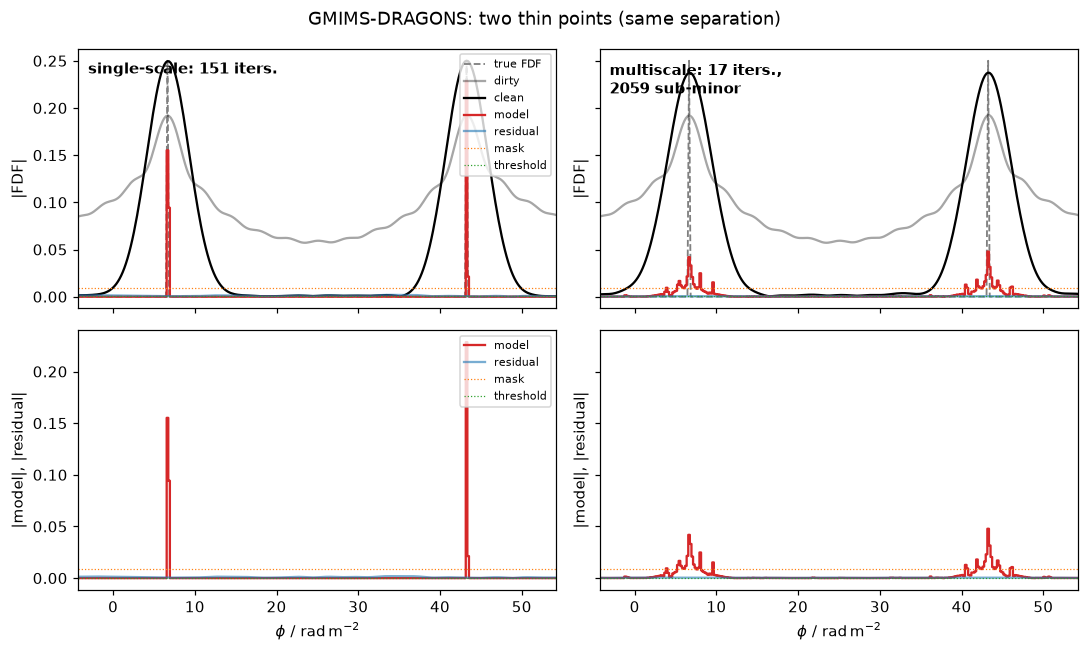

In [66]:
plot_clean(
    synth,
    single,
    multi,
    "points",
    delta_rm,
    rmsf_fwhm,
    "GMIMS-DRAGONS: two thin points (same separation)",
)

### The `scale_bias` tradeoff

`multiscale_scale_bias` (Offringa & Smirnov 2017, eq. 3) sets how strongly larger
scales are preferred: near 1 behaves like single-scale, lower favours larger
scales. Because the RMSF is broad relative to the scale kernels, the per-scale
peaks sit close together and selection is very sensitive to the bias, and there
is no free lunch:

- **0.95** (near 1): scale 0 almost always wins, so multiscale reduces to
  single-scale and a thin source stays a compact delta, but you lose the
  extended-model behaviour everywhere.
- **0.8** (our default): the scales engage on resolved structure, at the cost of
  spreading a compact source a little.
- **0.6** (WSClean's image-domain default): over-extends here, because its PSF is
  far narrower than the RMSF, inflating even a thin source.

We re-clean the thin GMIMS source at all three to show the progression.</cell id="34">

scale_bias=0.95: mom0=0.499 half-power width=31 chan
scale_bias=0.8: mom0=0.501 half-power width=32 chan
scale_bias=0.6: mom0=0.582 half-power width=38 chan


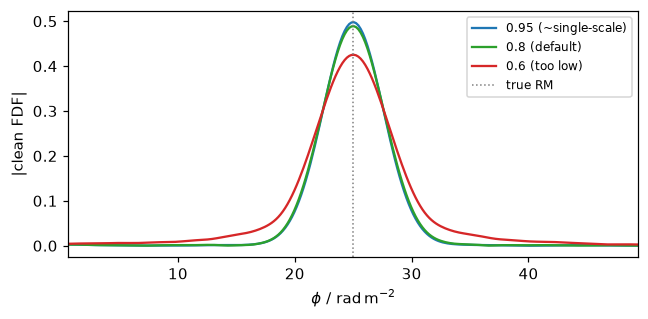

In [67]:
phi = synth_thin.fdf_arrs["phi_arr_radm2"].to_numpy().astype(float)
biases = {
    "0.95 (~single-scale)": SCALE_BIAS_HIGH,
    "0.8 (default)": SCALE_BIAS,
    "0.6 (too low)": SCALE_BIAS_LOW,
}
cleans, widths, mom0s = {}, {}, {}
with quiet_logs(logging.ERROR):
    for label, bias in biases.items():
        res = rmclean.run_rmclean_from_synth(
            synth_thin,
            auto_mask=AUTO_MASK,
            auto_threshold=AUTO_THRESHOLD,
            multiscale=True,
            multiscale_scale_bias=bias,
            multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
        )
        cl = np.abs(res.fdf_arrs["fdf_clean_complex_arr"].to_numpy().astype(complex))
        cleans[label] = cl
        widths[label] = int((cl > cl.max() / 2).sum())
        mom0s[label] = float(res.fdf_parameters["mom0_debias"][0])
        print(
            f"scale_bias={bias}: mom0={mom0s[label]:.3f} half-power width={widths[label]} chan"
        )

# Lowering scale_bias on a thin source inflates its flux and broadens its peak.
assert mom0s["0.6 (too low)"] > mom0s["0.95 (~single-scale)"]
assert widths["0.6 (too low)"] >= widths["0.95 (~single-scale)"]

fig, ax = plt.subplots(figsize=(6, 3))
for label, color in zip(biases, ("tab:blue", "tab:green", "tab:red"), strict=True):
    ax.plot(phi, cleans[label], color=color, label=label)
ax.axvline(RM_RADM2, color="0.5", ls=":", lw=1, label="true RM")
ax.set(
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="|clean FDF|",
    xlim=(RM_RADM2 - 4 * rmsf_fwhm, RM_RADM2 + 4 * rmsf_fwhm),
)
ax.legend(fontsize=8)
fig.tight_layout()

## When does multiscale actually help?

Every case above uses a physical Burn slab, and a Burn slab *depolarises*: its
$Q,U$ signal is attenuated at high $\lambda^2$, so a Faraday-thick source's flux
is genuinely reduced in the data. That is why multiscale matches single-scale on
flux throughout. Unlike synthesis imaging, where an extended source's flux is
present in the short baselines and only needs modelling, **"extended in Faraday
depth" means "depolarised"**: the missing flux is gone from the data, and no
CLEAN variant recovers it.

So multiscale buys no extra flux, and (as the counts show) no fewer components.
Its value shows up once the extended structure is genuinely detected. To see it
cleanly we switch source model (a smooth Gaussian FDF, i.e. external Faraday
dispersion, rather than a slab) and isolate the algorithm from depolarisation:
build the dirty directly as `true` $\ast$ `RMSF` $+$ `noise` with an **ideal,
sidelobe-free RMSF**. At matched flux, multiscale then leaves a **whiter
residual** (single-scale under-cleans the source and leaves structure above the
threshold) and models it as **one extended component** instead of a picket
fence.

One practical note: give multiscale a **generous $\phi$ window**, since scale
kernels wider than the window pick up reflect-mode edge artefacts. The mask
confines cleaning to significant channels, so a deep threshold (here $0.5\sigma$)
is safe.</cell id="8fc789bc">

single: mom0=68.99 resid on-source max/noise=5.97 component_steps=503 model spans 38 channels
 multi: mom0=68.99 resid on-source max/noise=1.23 component_steps=15217 model spans 316 channels


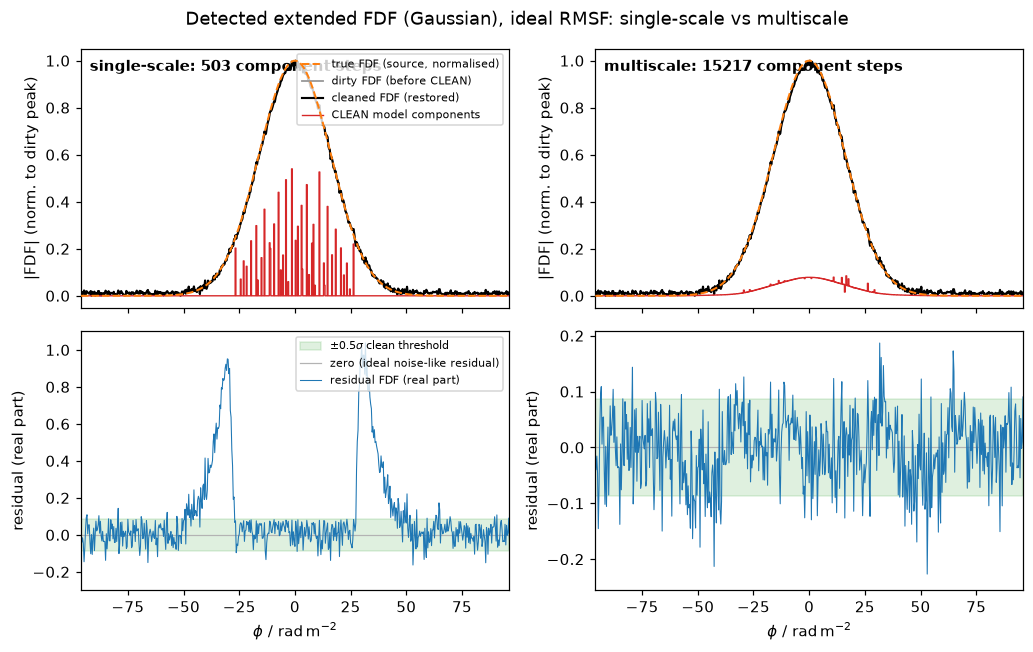

In [68]:
from rm_lite.utils.clean import rmclean as rmclean_lowlevel
from rm_lite.utils.fitting import unit_centred_gaussian
from rm_lite.utils.synthesis import calc_faraday_moments

# A different source MODEL: external Faraday dispersion, whose FDF is a smooth
# Gaussian (not a Burn slab tophat). Build the dirty directly as
# (true * ideal RMSF + noise), so the extended flux is genuinely in the data and
# the test is about the algorithm, not the coverage. Moderate S/N, so the
# per-channel extended flux sits near the noise (where single-scale struggles).
rng_ext = np.random.default_rng(0)
FWHM_IDEAL = 4.0
d_phi = FWHM_IDEAL / 12
phi_ideal = np.arange(-300, 300, d_phi)
phi2_ideal = np.arange(-600, 600, d_phi)
rmsf_ideal = unit_centred_gaussian(x=phi2_ideal, fwhm=FWHM_IDEAL).astype(complex)
rmsf_1d = unit_centred_gaussian(x=phi_ideal - phi_ideal.mean(), fwhm=FWHM_IDEAL)

sigma_rm = 4 * FWHM_IDEAL  # Gaussian FDF several RMSF FWHM wide
true_ext = FRAC_POL * np.exp(-(phi_ideal**2) / (2 * sigma_rm**2))
sigma_chan = 0.06
dirty_ext = (
    np.convolve(true_ext, rmsf_1d, mode="same")
    + rng_ext.normal(0, sigma_chan, phi_ideal.size)
    + 1j * rng_ext.normal(0, sigma_chan, phi_ideal.size)
).astype(np.complex128)
noise_ext = float(
    np.std(
        np.convolve(rng_ext.normal(0, sigma_chan, phi_ideal.size), rmsf_1d, mode="same")
    )
)

results_ext = {}
for use_multiscale in (False, True):
    with quiet_logs(logging.ERROR):
        results_ext[use_multiscale] = rmclean_lowlevel(
            dirty_fdf_arr=dirty_ext,
            phi_arr_radm2=phi_ideal,
            rmsf_arr=rmsf_ideal,
            phi_double_arr_radm2=phi2_ideal,
            fwhm_rmsf_arr=np.array(FWHM_IDEAL),
            mask=7 * noise_ext,
            threshold=0.5 * noise_ext,
            max_iter=5000,
            multiscale=use_multiscale,
            multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
        )

on_source = np.abs(phi_ideal) <= 3 * sigma_rm
metrics = {}
for use_multiscale, name in [(False, "single"), (True, "multi")]:
    res = results_ext[use_multiscale]
    clean = np.abs(res.clean_fdf_arr)
    resid = np.abs(res.resid_fdf_arr)
    model = np.abs(res.model_fdf_arr)
    metrics[name] = {
        "mom0": float(calc_faraday_moments(clean, phi_ideal, FWHM_IDEAL).mom0),
        "resid_on_max": float(resid[on_source].max() / noise_ext),
        "comps": int(np.ravel(res.sub_minor_iter_arr)[0]),
        "model_chan": int((model > 0.01 * model.max()).sum()),
    }
    print(
        f"{name:>6}: mom0={metrics[name]['mom0']:.2f} "
        f"resid on-source max/noise={metrics[name]['resid_on_max']:.2f} "
        f"component_steps={metrics[name]['comps']} "
        f"model spans {metrics[name]['model_chan']} channels"
    )

# Same flux, but multiscale leaves a lower on-source residual (single-scale
# under-cleans the extended source) and models it as one extended component
# instead of a picket fence. It does this with more component steps, not fewer.
assert np.isclose(metrics["single"]["mom0"], metrics["multi"]["mom0"], rtol=0.1)
assert metrics["multi"]["resid_on_max"] < metrics["single"]["resid_on_max"]
assert metrics["multi"]["model_chan"] > metrics["single"]["model_chan"]

# Top row: the FDF (source, dirty, cleaned, and the CLEAN model), all normalised
# to the dirty peak so shapes are comparable. Bottom row: the real part of the
# residual FDF (dirty minus the modelled source footprint) against the clean
# threshold band; a good clean leaves this as zero-mean noise inside the band.
fig, axs = plt.subplots(2, 2, figsize=(9.5, 6), sharex=True)
half = 6 * sigma_rm
norm = float(np.abs(dirty_ext).max())
for col, (use_multiscale, name) in enumerate(
    [(False, "single-scale"), (True, "multiscale")]
):
    res = results_ext[use_multiscale]
    comps = int(np.ravel(res.sub_minor_iter_arr)[0])
    ax = axs[0, col]
    ax.plot(
        phi_ideal,
        true_ext / true_ext.max(),
        color="tab:orange",
        ls="--",
        lw=1.3,
        label="true FDF (source, normalised)",
        zorder=1000,
    )
    ax.plot(
        phi_ideal,
        np.abs(dirty_ext) / norm,
        color="0.6",
        lw=1.2,
        label="dirty FDF (before CLEAN)",
    )
    ax.plot(
        phi_ideal,
        np.abs(res.clean_fdf_arr) / norm,
        color="k",
        lw=1.4,
        label="cleaned FDF (restored)",
    )
    ax.step(
        phi_ideal,
        np.abs(res.model_fdf_arr) / norm,
        color="tab:red",
        where="mid",
        lw=0.9,
        label="CLEAN model components",
    )
    ax.set(ylabel="|FDF| (norm. to dirty peak)")
    ax.text(
        0.02,
        0.96,
        f"{name}: {comps} component steps",
        transform=ax.transAxes,
        va="top",
        fontweight="bold",
    )
    axr = axs[1, col]
    axr.axhspan(
        -0.5 * noise_ext,
        0.5 * noise_ext,
        color="tab:green",
        alpha=0.15,
        label=r"$\pm 0.5\sigma$ clean threshold",
    )
    axr.axhline(0.0, color="0.7", lw=0.8, label="zero (ideal noise-like residual)")
    axr.plot(
        phi_ideal,
        res.resid_fdf_arr.real,
        color="tab:blue",
        lw=0.7,
        label="residual FDF (real part)",
    )
    axr.set(
        xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
        ylabel="residual (real part)",
        xlim=(-half, half),
    )
axs[0, 0].legend(fontsize=7, loc="upper right")
axs[1, 0].legend(fontsize=7, loc="upper right")
fig.suptitle("Detected extended FDF (Gaussian), ideal RMSF: single-scale vs multiscale")
fig.tight_layout()

## Uniform-$\lambda^2$ coverage

Real receivers sample uniformly in frequency, which clusters the $\lambda^2$
samples and gives the RMSF strong sidelobes. Sampling uniformly in $\lambda^2$ is
contrived but gives the cleanest RMSF, a useful reference. On a thick slab both
algorithms recover comparable flux (the slab still depolarises); multiscale uses
fewer minor cycles but, as everywhere, not fewer component steps. We will revisit
this once low-$\lambda^2$ up-weighting (the `new-weights` schemes) lands:
weighting the near-DC channels up should lift the extended Faraday structure out
of the noise and let multiscale's model advantage show more clearly here.</cell id="91658be0">

uniform-lambda^2 RMSF FWHM = 4.0 rad/m^2, dRM = 8 rad/m^2
single: mom0=0.211 iterations=215
multi:  mom0=0.212 minor_cycles=7 component_steps=325


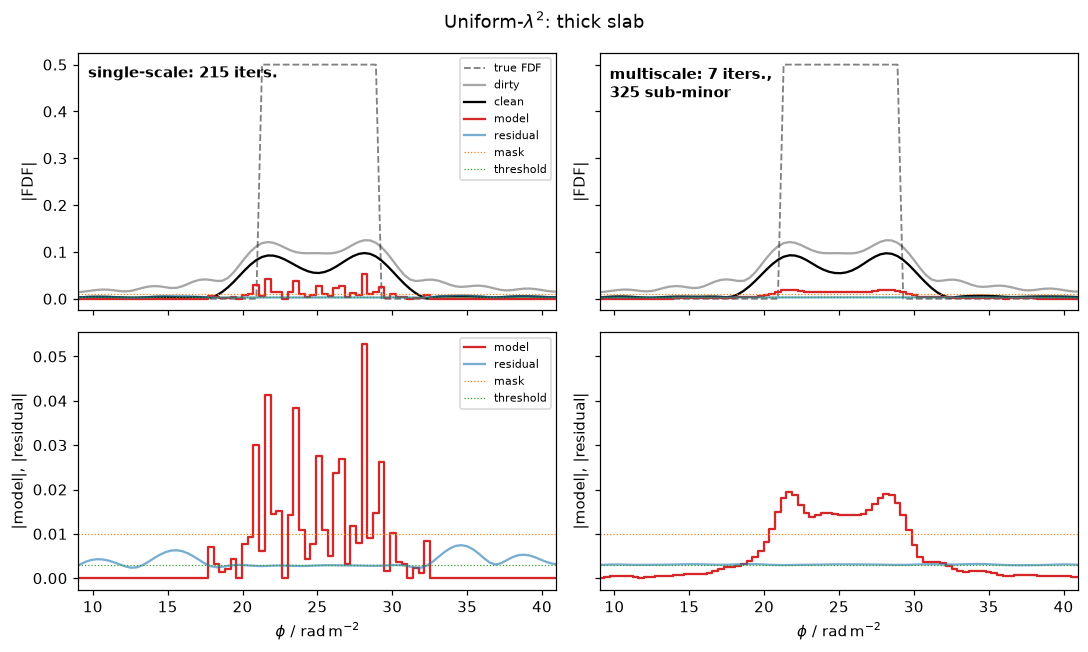

In [69]:
from rm_lite.utils.synthesis import lambda2_to_freq

# Uniform in lambda^2 (contrived) -> the cleanest RMSF. A generous phi window
# (phi_max_radm2) gives the extended model room; narrow windows breed edge
# artefacts in multiscale.
lambda_sq_uniform = np.linspace(0.001, 1.0, 400)
freq_uniform = lambda2_to_freq(lambda_sq_uniform)

with quiet_logs(logging.ERROR):
    synth_u_thin = rmsynth.run_rmsynth(
        freq_uniform,
        burn_slab(lambda_sq_uniform, 0.0),
        np.ones_like(lambda_sq_uniform) * (RMS_NOISE + 1j * RMS_NOISE),
        phi_max_radm2=600.0,
        do_fit_rmsf=True,
    )
rmsf_fwhm_u = float(synth_u_thin.fdf_parameters["fwhm_rmsf_radm2"][0])
delta_rm_u = 2 * rmsf_fwhm_u

pol = (
    burn_slab(lambda_sq_uniform, delta_rm_u)
    + rng.normal(0, RMS_NOISE, freq_uniform.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_uniform.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(
        freq_uniform, pol, err, phi_max_radm2=600.0, do_fit_rmsf=True
    )
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=3
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=3,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0, single_n, _ = clean_stats(single)
multi_mom0, multi_minor, multi_comps = clean_stats(multi)
print(
    f"uniform-lambda^2 RMSF FWHM = {rmsf_fwhm_u:.1f} rad/m^2, "
    f"dRM = {delta_rm_u:.0f} rad/m^2"
)
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} minor_cycles={multi_minor} "
    f"component_steps={multi_comps}"
)

# Comparable flux (the slab still depolarises).
assert multi_mom0 > 0.75 * single_mom0

plot_clean(
    synth, single, multi, "slab", delta_rm_u, rmsf_fwhm_u, r"Uniform-$\lambda^2$: thick slab"
)

## Summary

| Regime | $\Delta\phi$ / FWHM | Multiscale vs single-scale |
|---|---|---|
| Thin | 0 | matches flux; at bias 0.8 the model spreads slightly (compact only near bias 1) |
| Marginal | ~1 | comparable flux |
| Resolved thick | few (if coverage allows) | comparable flux, model spread across the slab |
| Two thin points | any separation | full (undepolarised) flux, model less extended than the slab |
| Detected extended, ideal RMSF | several | same flux, whiter residual, one extended component |

The key points:

- **No extra flux.** Unlike synthesis imaging, "extended in Faraday depth" means
  "depolarised", so a thick source's flux is physically attenuated in the data,
  not merely hard to model; CLEAN conserves flux and multiscale invents none.
- **Not fewer components.** Multiscale converges in fewer *minor cycles*, but in
  realistic (sidelobe-rich) RMSFs it places *more* component-placement steps than
  single-scale, not fewer. Only with an idealised RMSF does it also win on count.
- **The genuine value is the model:** source-matched (extended for a slab), and
  in favourable conditions a whiter residual. Detection is set by the coverage
  (dense low-$\lambda^2$ / high frequency, or up-weighting low-$\lambda^2$), not
  by the algorithm.

The mask confines cleaning to significant channels, so a deep clean threshold
(these runs use $0.5\sigma$) is safe. Enable multiscale with `multiscale=True` on
`run_rmclean_from_synth` (1D) or `rmclean_3d_from_synth` (3D). Give it a generous
$\phi$ window; tune with `multiscale_scale_bias` (default 0.8; towards 1 reduces
to single-scale, below ~0.6 over-extends compact sources),
`multiscale_max_iter_sub_minor`, and the usual `auto_mask` / `auto_threshold`.</cell id="36">